# Unidad 1. Fundamentos del aprendizaje automático
## Evaluación básica de modelos con un ejemplo de productos

Este notebook trabaja un solo ejemplo durante toda la práctica: una tabla de productos.
Incluye estadística descriptiva, gráficas, clasificación, matriz de confusión, Accuracy, Precisión, Recall, separación entrenamiento/prueba y validación cruzada.

## 0. Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 1. Nuestro ejemplo: una tienda de productos

Cada fila representa un producto y contiene: `id_producto`, `precio`, `stock`, `calificacion` y `ventas_mes`.

In [2]:
productos = pd.DataFrame({
    "id_producto": list(range(1, 21)),
    "precio": [
        120, 85, 250, 310, 150, 99, 450, 210, 180, 75,
        390, 130, 275, 160, 220, 95, 340, 200, 145, 290
    ],
    "stock": [
        45, 80, 30, 25, 60, 95, 20, 40, 50, 100,
        15, 70, 35, 55, 42, 90, 18, 48, 65, 28
    ],
    "calificacion": [
        4, 3, 5, 4, 4, 3, 5, 4, 4, 2,
        5, 3, 5, 4, 4, 3, 5, 4, 3, 5
    ],
    "ventas_mes": [
        170, 90, 230, 180, 160, 75, 260, 155, 145, 60,
        250, 110, 220, 150, 165, 80, 240, 175, 120, 210
    ]
})

productos

,id_producto,precio,stock,calificacion,ventas_mes
0,1,120,45,4,170
1,2,85,80,3,90
2,3,250,30,5,230
3,4,310,25,4,180
4,5,150,60,4,160
5,6,99,95,3,75
6,7,450,20,5,260
7,8,210,40,4,155
8,9,180,50,4,145
9,10,75,100,2,60


## 2. Nube de puntos: información de los productos

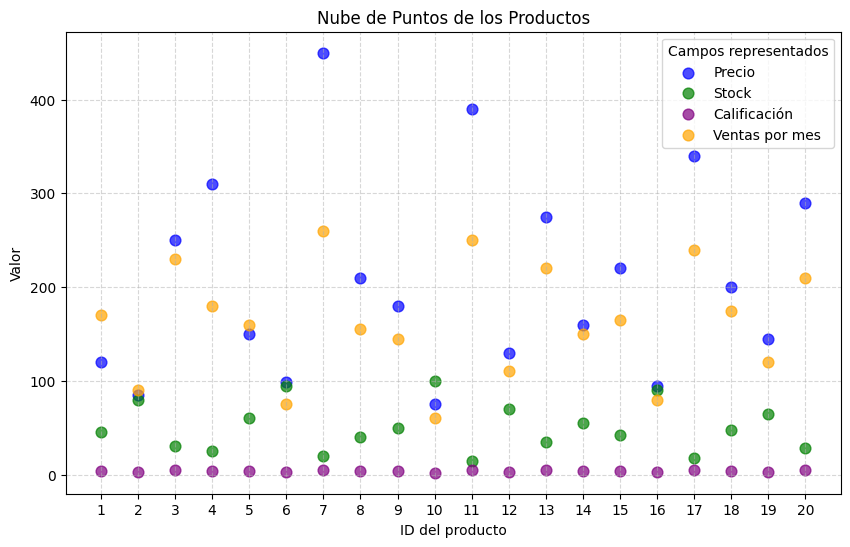

In [3]:
plt.figure(figsize=(10, 6))

campos = [
    'precio',
    'stock',
    'calificacion',
    'ventas_mes'
]

colores = {
    'precio': 'blue',
    'stock': 'green',
    'calificacion': 'purple',
    'ventas_mes': 'orange'
}

etiquetas = {
    'precio': 'Precio',
    'stock': 'Stock',
    'calificacion': 'Calificación',
    'ventas_mes': 'Ventas por mes'
}

for col in campos:
    plt.scatter(
        productos['id_producto'],
        productos[col],
        label=etiquetas[col],
        color=colores[col],
        alpha=0.7,
        s=60
    )

plt.title("Nube de Puntos de los Productos")
plt.xlabel("ID del producto")
plt.ylabel("Valor")
plt.xticks(productos['id_producto'])
plt.legend(title="Campos representados")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Estadística descriptiva

Calculamos media, mediana, moda y desviación estándar.

In [4]:
precio_promedio = productos["precio"].mean()
precio_mediana = productos["precio"].median()
calificacion_moda = productos["calificacion"].mode()[0]
desviacion_ventas = productos["ventas_mes"].std()

print("Precio promedio: $", round(precio_promedio, 2))
print("Mediana del precio: $", round(precio_mediana, 2))
print("Calificación más frecuente:", calificacion_moda)
print("Desviación estándar de las ventas:", round(desviacion_ventas, 2))

Precio promedio: $ 208.7
Mediana del precio: $ 190.0
Calificación más frecuente: 4
Desviación estándar de las ventas: 60.32


## Actividad 1: primeros cinco productos

In [6]:
primeras_ventas = productos["ventas_mes"].head(5)
print("Ventas:", list(primeras_ventas))
print("Promedio:", primeras_ventas.mean())
print("Máximo:", primeras_ventas.max())
print("Mínimo:", primeras_ventas.min())

Ventas: [170, 90, 230, 180, 160]
Promedio: 166.0
Máximo: 230
Mínimo: 90


## 4. Ventas mensuales por producto

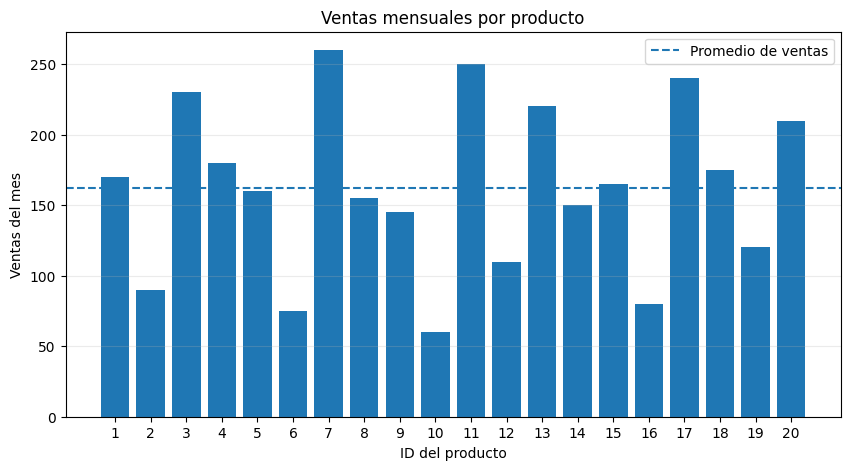

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(productos["id_producto"], productos["ventas_mes"])
plt.axhline(
    productos["ventas_mes"].mean(),
    linestyle="--",
    label="Promedio de ventas"
)
plt.title("Ventas mensuales por producto")
plt.xlabel("ID del producto")
plt.ylabel("Ventas del mes")
plt.xticks(productos["id_producto"])
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

## 5. Boxplot: media, mediana y valores atípicos

In [8]:
precios = productos["precio"]

media_precio = precios.mean()
mediana_precio = precios.median()
q1 = precios.quantile(0.25)
q3 = precios.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = precios[
    (precios < limite_inferior) |
    (precios > limite_superior)
]

print("Media:", round(media_precio, 2))
print("Mediana:", round(mediana_precio, 2))
print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))

if len(outliers) == 0:
    print("No se detectaron valores atípicos.")
else:
    print("Valores atípicos:", list(outliers))

Media: 208.7
Mediana: 190.0
Q1: 127.5
Q3: 278.75
IQR: 151.25
Límite inferior: -99.38
Límite superior: 505.62
No se detectaron valores atípicos.


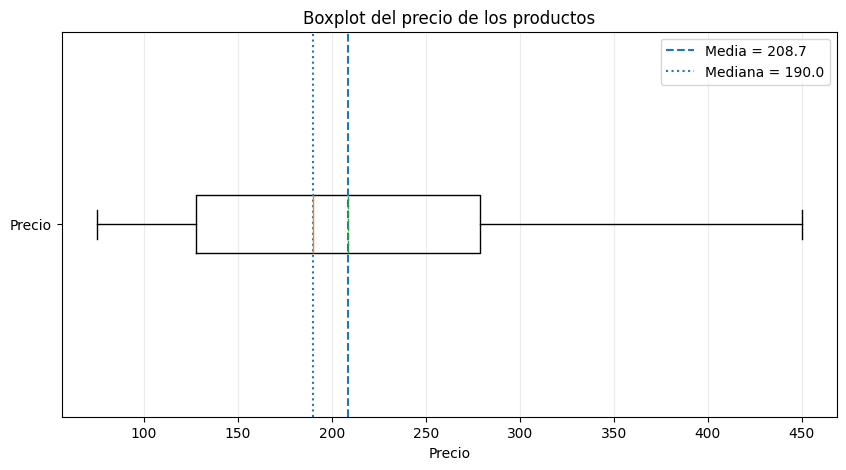

In [9]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    precios,
    vert=False,
    showmeans=True,
    meanline=True
)

plt.axvline(
    media_precio,
    linestyle="--",
    label=f"Media = {media_precio:.1f}"
)
plt.axvline(
    mediana_precio,
    linestyle=":",
    label=f"Mediana = {mediana_precio:.1f}"
)
plt.title("Boxplot del precio de los productos")
plt.xlabel("Precio")
plt.yticks([1], ["Precio"])
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.show()

## 6. Campana de Gauss con nube de puntos

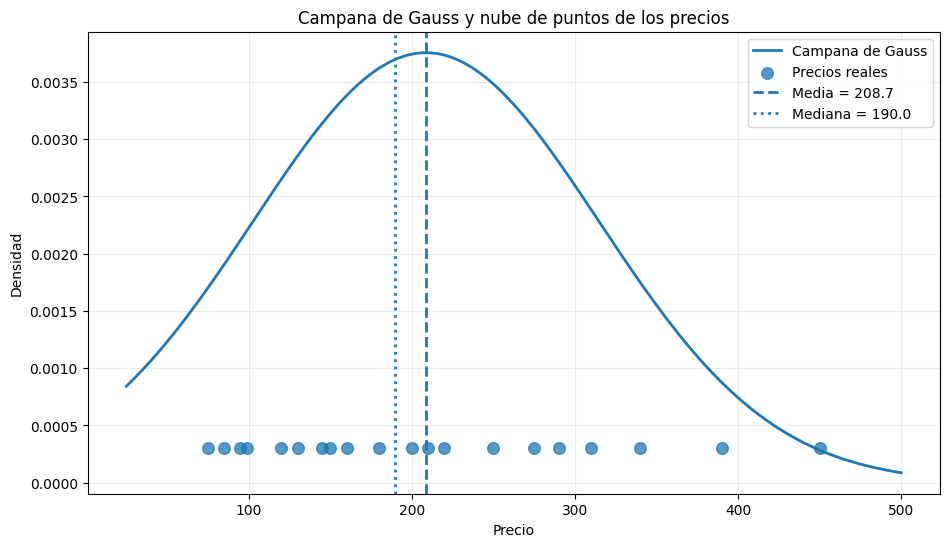

In [10]:
mu = precios.mean()
sigma = precios.std()

x = np.linspace(
    precios.min() - 50,
    precios.max() + 50,
    400
)

y = (
    1 / (sigma * np.sqrt(2 * np.pi))
) * np.exp(
    -0.5 * ((x - mu) / sigma) ** 2
)

plt.figure(figsize=(11, 6))
plt.plot(x, y, linewidth=2, label="Campana de Gauss")

altura_puntos = np.full(len(precios), y.max() * 0.08)
plt.scatter(
    precios,
    altura_puntos,
    s=70,
    alpha=0.75,
    label="Precios reales"
)

plt.axvline(
    mu,
    linestyle="--",
    linewidth=2,
    label=f"Media = {mu:.1f}"
)
plt.axvline(
    mediana_precio,
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {mediana_precio:.1f}"
)

if len(outliers) > 0:
    altura_outliers = np.full(len(outliers), y.max() * 0.08)
    plt.scatter(
        outliers,
        altura_outliers,
        marker="x",
        s=120,
        linewidths=2.5,
        label="Outliers"
    )

plt.title("Campana de Gauss y nube de puntos de los precios")
plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 7. Definimos el problema de clasificación

Un producto será considerado un **éxito de ventas** cuando venda 150 unidades o más durante el mes.

In [11]:
productos["exito_real"] = (productos["ventas_mes"] >= 150).astype(int)
productos[["id_producto", "ventas_mes", "exito_real"]]

,id_producto,ventas_mes,exito_real
0,1,170,1
1,2,90,0
2,3,230,1
3,4,180,1
4,5,160,1
5,6,75,0
6,7,260,1
7,8,155,1
8,9,145,0
9,10,60,0


## 8. Simulamos las predicciones de un modelo

In [12]:
productos["prediccion_modelo"] = [
    1, 0, 1, 1, 1,
    0, 1, 1, 0, 0,
    1, 0, 1, 1, 1,
    0, 1, 0, 0, 1
]

productos[[
    "id_producto",
    "ventas_mes",
    "exito_real",
    "prediccion_modelo"
]]

,id_producto,ventas_mes,exito_real,prediccion_modelo
0,1,170,1,1
1,2,90,0,0
2,3,230,1,1
3,4,180,1,1
4,5,160,1,1
5,6,75,0,0
6,7,260,1,1
7,8,155,1,1
8,9,145,0,0
9,10,60,0,0


## 9. Matriz de confusión

In [13]:
y_real = productos["exito_real"]
y_pred = productos["prediccion_modelo"]

cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Verdaderos Positivos (VP):", tp)
print("Verdaderos Negativos (VN):", tn)
print("Falsos Positivos (FP):", fp)
print("Falsos Negativos (FN):", fn)

Verdaderos Positivos (VP): 12
Verdaderos Negativos (VN): 7
Falsos Positivos (FP): 0
Falsos Negativos (FN): 1


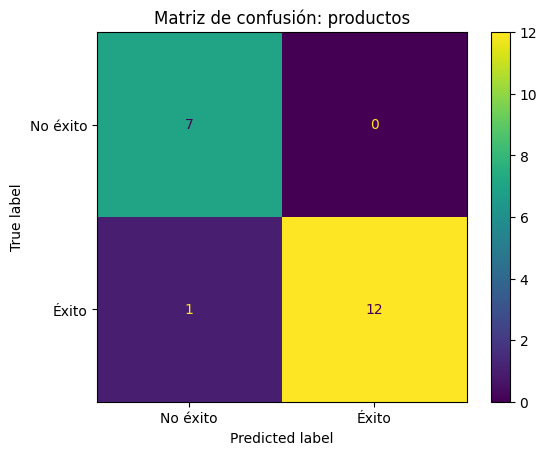

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No éxito", "Éxito"]
)
disp.plot()
plt.title("Matriz de confusión: productos")
plt.show()

## 10. Accuracy

In [14]:
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)
accuracy_python = accuracy_score(y_real, y_pred)

print("Accuracy manual:", round(accuracy_manual, 3))
print("Accuracy con Python:", round(accuracy_python, 3))
print("Accuracy en porcentaje:", round(accuracy_python * 100, 1), "%")

Accuracy manual: 0.95
Accuracy con Python: 0.95
Accuracy en porcentaje: 95.0 %


## 11. Precisión

In [16]:
precision_manual = tp / (tp + fp)
precision_python = precision_score(y_real, y_pred)

print("Precisión manual:", round(precision_manual, 3))
print("Precisión con Python:", round(precision_python, 3))
print("Precisión en porcentaje:", round(precision_python * 100, 1), "%")

Precisión manual: 1.0
Precisión con Python: 1.0
Precisión en porcentaje: 100.0 %


## 12. Recall

In [17]:
recall_manual = tp / (tp + fn)
recall_python = recall_score(y_real, y_pred)

print("Recall manual:", round(recall_manual, 3))
print("Recall con Python:", round(recall_python, 3))
print("Recall en porcentaje:", round(recall_python * 100, 1), "%")

Recall manual: 0.923
Recall con Python: 0.923
Recall en porcentaje: 92.3 %


## 13. Comparamos las tres métricas

In [18]:
resumen = pd.DataFrame({
    "Métrica": ["Accuracy", "Precisión", "Recall"],
    "Valor": [accuracy_python, precision_python, recall_python],
    "Porcentaje": [
        accuracy_python * 100,
        precision_python * 100,
        recall_python * 100
    ]
})

resumen.round(2)

,Métrica,Valor,Porcentaje
0,Accuracy,0.95,95.00
1,Precisión,1.00,100.00
2,Recall,0.92,92.31


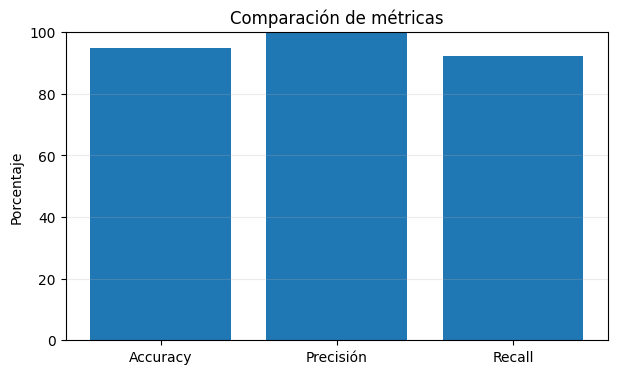

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(resumen["Métrica"], resumen["Porcentaje"])
plt.ylim(0, 100)
plt.ylabel("Porcentaje")
plt.title("Comparación de métricas")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 14. Separación entre entrenamiento y prueba

Usaremos `precio`, `stock` y `calificacion` para predecir `exito_real`.

In [20]:
X = productos[["precio", "stock", "calificacion"]]
y = productos["exito_real"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Productos para entrenamiento:", len(X_train))
print("Productos para prueba:", len(X_test))

Productos para entrenamiento: 14
Productos para prueba: 6


## 15. Entrenamos un modelo sencillo

In [21]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
pred_test = modelo.predict(X_test)

print("Predicciones realizadas sobre los datos de prueba.")

resultado_prueba = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": pred_test
})

resultado_prueba

Predicciones realizadas sobre los datos de prueba.


,Real,Predicción
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1


In [22]:
acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0)
rec_test = recall_score(y_test, pred_test, zero_division=0)

print("Accuracy:", round(acc_test, 3))
print("Precisión:", round(prec_test, 3))
print("Recall:", round(rec_test, 3))

Accuracy: 1.0
Precisión: 1.0
Recall: 1.0


## 16. Validación cruzada

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy en cada fold:")
for i, valor in enumerate(resultados_cv, start=1):
    print(f"Fold {i}: {valor:.2f}")

print("\nAccuracy promedio:", round(resultados_cv.mean(), 3))

Accuracy en cada fold:
Fold 1: 1.00
Fold 2: 1.00
Fold 3: 0.75
Fold 4: 0.75
Fold 5: 1.00

Accuracy promedio: 0.9


## 17. Actividad final

### Parte A. Estadística
1. Calcula el promedio de `stock`.
2. Calcula la mediana de `ventas_mes`.
3. Encuentra la moda de `calificacion`.
4. Explica cada resultado con una oración.

### Parte B. Evaluación del modelo
Usa VP = 8, VN = 7, FP = 3 y FN = 2 para calcular Accuracy, Precisión y Recall.

### Parte C. Interpretación
Escribe tres frases explicando qué significan Accuracy, Precisión y Recall en el ejemplo de productos.

In [24]:
# Parte A
promedio_stock = productos["stock"].mean()
mediana_ventas = productos["ventas_mes"].median()
moda_calificacion = productos["calificacion"].mode()[0]

print("Promedio de stock:", round(promedio_stock, 2))
print("Mediana de ventas_mes:", round(mediana_ventas, 2))
print("Moda de calificacion:", moda_calificacion)

# Parte B
vp = 8
vn = 7
fp = 3
fn = 2

accuracy_actividad = (vp + vn) / (vp + vn + fp + fn)
precision_actividad = vp / (vp + fp)
recall_actividad = vp / (vp + fn)

print("\nResultados de la actividad final:")
print("Accuracy:", round(accuracy_actividad, 3))
print("Precisión:", round(precision_actividad, 3))
print("Recall:", round(recall_actividad, 3))

Promedio de stock: 50.55
Mediana de ventas_mes: 162.5
Moda de calificacion: 4

Resultados de la actividad final:
Accuracy: 0.75
Precisión: 0.727
Recall: 0.8


## 18. Resumen

- Media, mediana, moda y desviación estándar ayudan a comprender los datos.
- La clasificación convierte el problema en categorías como éxito y no éxito.
- VP, VN, FP y FN forman la base de la matriz de confusión.
- Accuracy mide los aciertos totales.
- Precisión indica qué tan confiables son las predicciones positivas.
- Recall indica cuántos positivos reales fueron detectados.
- La separación entrenamiento/prueba permite evaluar con datos que el modelo no utilizó para aprender.
- La validación cruzada permite evaluar el comportamiento del modelo en diferentes particiones.